# Life Expectancy Prediction - Regression

This project predicts life expectancy across countries and years from a set of socioeconomic and health indicators (income, education, healthcare access, immunization coverage, etc.). 

The goals were to 
(1) build a clean, well-justified preprocessing pipeline for a real-world, fairly messy dataset, 
(2) implement a Random Forest regressor from scratch on top of scikit-learn's decision trees, 
(3) compare it against Ridge Regression and AdaBoost, and 
(4) pick a final model based on validation performance and generate predictions on a held-out evaluation set.

**Dataset features**

* `Year` - year of the record
* `Status` - whether the country is classified as *Developed* or *Developing*
* `Life expectancy` - target variable, in years
* `Adult Mortality` - probability of dying between 15 and 60 years of age, per 1,000 population
* `infant deaths` - infant deaths per 1,000 population
* `Alcohol` - recorded alcohol consumption per capita (15+), litres of pure alcohol
* `percentage expenditure` - health expenditure as a share of GDP per capita (%)
* `Hepatitis B` - HepB immunization coverage among 1-year-olds (%)
* `Measles` - reported measles cases per 1,000 population
* `BMI` - average body mass index of the population
* `under-five deaths` - deaths of children under five per 1,000 population
* `Polio` - Pol3 immunization coverage among 1-year-olds (%)
* `Total expenditure` - government health expenditure as a share of total government expenditure (%)
* `Diphtheria` - DTP3 immunization coverage among 1-year-olds (%)
* `HIV/AIDS` - deaths per 1,000 live births due to HIV/AIDS (ages 0-4)
* `GDP` - GDP per capita (USD)
* `Population` - country population
* `thinness 10-19 years` - share of 10-19 year-olds with BMI more than 2 standard deviations below the median (%)
* `thinness 5-9 years` - share of 5-9 year-olds with BMI more than 2 standard deviations below the median (%)
* `Income composition of resources` - Human Development Index component for income (0-1)
* `Schooling` - average years of schooling

## 1. Data loading and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import AdaBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer

RANDOM_STATE = 333

/home/daria/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/daria/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/daria/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('data.csv')

Quick look at the data and the feature types:

In [3]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2718 entries, 0 to 2717
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2718 non-null   object 
 1   Year                             2718 non-null   int64  
 2   Status                           2718 non-null   object 
 3   Life expectancy                  2718 non-null   float64
 4   Adult Mortality                  2718 non-null   float64
 5   infant deaths                    2718 non-null   int64  
 6   Alcohol                          2564 non-null   float64
 7   percentage expenditure           2718 non-null   float64
 8   Hepatitis B                      2188 non-null   float64
 9   Measles                          2718 non-null   int64  
 10  BMI                              2692 non-null   float64
 11  under-five deaths                2718 non-null   int64  
 12  Polio               

## 2. Exploratory data analysis and cleaning

### 2.1 Fixing the `Status` feature

The dataset only has two development-status labels, and the *Developed* list looked incomplete - countries such as Canada or France were missing. Since the records span 2000-2015, a country's status may genuinely have changed over that period, but for this dataset I only care about a consistent, reasonable label, so I re-classified a handful of countries to *Developed* using current IMF/UN classifications. This is a fixed, external rule rather than anything derived from the data itself, so applying it before the train/test split doesn't raise any leakage concerns.

In [5]:
developed_countries = df[df['Status'] == 'Developed']['Country'].unique()
developed_countries

array(['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Germany', 'Hungary', 'Iceland', 'Ireland',
       'Italy', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
       'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal',
       'Romania', 'Singapore', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland',
       'United Kingdom of Great Britain and Northern Ireland',
       'United States of America'], dtype=object)

In [6]:
countries_to_update = ['Canada', 'France', 'Republic of Korea', 'Finland', 'Estonia', 'Greece', 'Israel']
df.loc[df['Country'].isin(countries_to_update), 'Status'] = 'Developed'
df[df['Status'] == 'Developed']['Country'].unique()

array(['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Canada', 'Croatia',
       'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France',
       'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel',
       'Italy', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
       'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal',
       'Republic of Korea', 'Romania', 'Singapore', 'Slovakia',
       'Slovenia', 'Spain', 'Sweden', 'Switzerland',
       'United Kingdom of Great Britain and Northern Ireland',
       'United States of America'], dtype=object)

### 2.2 Encoding categorical features

`Country` and `Status` are converted to numeric codes so they can be used directly by the models. I fix the category *vocabulary* (the list of possible country names and statuses) at this point and reuse it later for the evaluation set, so a given code always refers to the same country everywhere in the pipeline - encoding the evaluation set independently would silently reassign codes to different countries and corrupt the `Country` feature without raising any error.

Note that this is different from the train/test-only rule I apply below to things like medians and correlation-based decisions: fixing a *vocabulary* of category names doesn't use the target at all and doesn't bias any evaluation metric, so there's no leakage concern in defining it from the full dataset - it's the categorical equivalent of already knowing which countries exist in the world.

In [7]:
country_categories = df['Country'].astype('category').cat.categories
status_categories = df['Status'].astype('category').cat.categories

df['Country'] = pd.Categorical(df['Country'], categories=country_categories).codes
df['Status'] = pd.Categorical(df['Status'], categories=status_categories).codes

df.dtypes

Country                              int16
Year                                 int64
Status                                int8
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

### 2.3 Checking feature quality

While scanning the raw values I noticed `Population` jumping wildly for the same country between consecutive years (e.g. Albania goes from ~295k to ~2.9k and back to ~289k across three years), which is not physically plausible and points to a data quality issue rather than a real trend. Whether to actually drop it is a decision I make later using only the training data (section 4) - using a correlation computed over the full dataset, including validation and test rows, to decide which features to keep would leak information into what's supposed to be an unbiased evaluation.

I also noticed the raw column name `thinness  1-19 years` (double space, and an inconsistent age range next to `thinness 5-9 years`) - it's clearly meant to be `10-19 years`, so I renamed it for clarity.

In [8]:
df = df.rename(columns={'thinness  1-19 years': 'thinness 10-19 years'})

### 2.4 Range validation

Several numeric features are rates or percentages that can only fall within a fixed range (e.g. a percentage cannot exceed 100, and a per-1,000 rate cannot exceed 1,000). I flagged out-of-range values and treated them as missing rather than silently trusting them. Unlike the median imputation and feature-selection steps later, these bounds are fixed domain knowledge, not statistics estimated from the data, so applying them before the split doesn't leak anything either.

In [9]:
range_checks = {
    'Adult Mortality': lambda x: 0 <= x <= 1000,
    'infant deaths': lambda x: 0 <= x <= 1000,
    'percentage expenditure': lambda x: 0 <= x <= 100,
    'Hepatitis B': lambda x: 0 <= x <= 100,
    'Measles': lambda x: 0 <= x <= 1000,
    'under-five deaths': lambda x: 0 <= x <= 1000,
    'Polio': lambda x: 0 <= x <= 100,
    'Total expenditure': lambda x: 0 <= x <= 100,
    'Diphtheria': lambda x: 0 <= x <= 100,
    'HIV/AIDS': lambda x: 0 <= x <= 1000,
    'thinness 10-19 years': lambda x: 0 <= x <= 1000,
    'thinness 5-9 years': lambda x: 0 <= x <= 1000,
    'Income composition of resources': lambda x: 0 <= x <= 1,
}

for feature, is_valid in range_checks.items():
    n_invalid = df[~df[feature].apply(is_valid)][feature].count()
    print(f'Out-of-range values in "{feature}": {n_invalid}')

for feature, is_valid in range_checks.items():
    df.loc[~df[feature].apply(is_valid), feature] = np.nan

Out-of-range values in "Adult Mortality": 0
Out-of-range values in "infant deaths": 13
Out-of-range values in "percentage expenditure": 1220
Out-of-range values in "Hepatitis B": 0
Out-of-range values in "Measles": 490
Out-of-range values in "under-five deaths": 16
Out-of-range values in "Polio": 0
Out-of-range values in "Total expenditure": 0
Out-of-range values in "Diphtheria": 0
Out-of-range values in "HIV/AIDS": 0
Out-of-range values in "thinness 10-19 years": 0
Out-of-range values in "thinness 5-9 years": 0
Out-of-range values in "Income composition of resources": 0


This should confirm that every out-of-range value was caught - all counts below should be zero.

In [10]:
for feature, is_valid in range_checks.items():
    n_invalid = df[~df[feature].apply(is_valid)][feature].count()
    print(f'Out-of-range values in "{feature}" after fixing: {n_invalid}')

Out-of-range values in "Adult Mortality" after fixing: 0
Out-of-range values in "infant deaths" after fixing: 0
Out-of-range values in "percentage expenditure" after fixing: 0
Out-of-range values in "Hepatitis B" after fixing: 0
Out-of-range values in "Measles" after fixing: 0
Out-of-range values in "under-five deaths" after fixing: 0
Out-of-range values in "Polio" after fixing: 0
Out-of-range values in "Total expenditure" after fixing: 0
Out-of-range values in "Diphtheria" after fixing: 0
Out-of-range values in "HIV/AIDS" after fixing: 0
Out-of-range values in "thinness 10-19 years" after fixing: 0
Out-of-range values in "thinness 5-9 years" after fixing: 0
Out-of-range values in "Income composition of resources" after fixing: 0


Not every feature had invalid values, but it was worth checking all of them systematically rather than guessing which ones might be affected.

## 3. Train / validation / test split

I split the data 60% train, 20% validation, and 20% test. From here on, every statistic used to make a modeling decision - which features to keep, what value to impute for a missing entry, which hyperparameters to use - is computed on `X_train`/`y_train` only, and then applied unchanged to validation, test, and later the evaluation set. That's what keeps the validation and test scores an honest estimate of performance on unseen data.

For hyperparameter tuning specifically, I use 5-fold cross-validation *within* `X_train` for each model family (Random Forest, Ridge, AdaBoost) - this gives a more robust hyperparameter choice than tuning against a single validation split would, since it isn't sensitive to which particular rows happened to land in that split. The validation set is then used only for the second, separate decision of comparing the three tuned model families against each other, and the test set is reserved for a single, final, unbiased performance estimate of the winning model. So the cross-validation and the validation set aren't doing the same job - they answer two different questions (best hyperparameters *within* a model family, versus best model family overall) - rather than being a redundant double-check on the same thing.

In [11]:
X = df.drop('Life expectancy', axis=1)
y = df['Life expectancy']

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

X_train.shape, X_val.shape, X_test.shape

((1630, 21), (544, 21), (544, 21))

## 4. Feature selection and missing values

### 4.1 Deciding whether to drop `Population`

Now that the split has happened, I can check `Population`'s correlation with the target using the training data only, and use that -together with the data-quality issue noticed above - to decide whether to drop it.

In [13]:
train_with_target = X_train.copy()
train_with_target['Life expectancy'] = y_train

correlation_matrix = train_with_target.corr()
life_expectancy_correlation = correlation_matrix['Life expectancy']
life_expectancy_correlation

Country                           -0.020958
Year                               0.159413
Status                            -0.531485
Adult Mortality                   -0.690443
infant deaths                     -0.292663
Alcohol                            0.371636
percentage expenditure            -0.092180
Hepatitis B                        0.279369
Measles                           -0.265726
BMI                                0.563906
under-five deaths                 -0.366815
Polio                              0.490134
Total expenditure                  0.228335
Diphtheria                         0.484285
HIV/AIDS                          -0.552903
GDP                                0.458213
Population                        -0.032637
thinness 10-19 years              -0.471367
thinness 5-9 years                -0.461186
Income composition of resources    0.726155
Schooling                          0.749200
Life expectancy                    1.000000
Name: Life expectancy, dtype: fl

`Population` has very weak correlation with `Life expectancy` even measured on the training data alone, so on top of being unreliable it also isn't useful - I dropped it from all three splits. `Country` also correlates weakly, but I wouldn't read much into that number either way: it's an arbitrarily-assigned integer code with no real ordering, so a linear correlation coefficient isn't a meaningful way to judge whether it matters (a tree-based model doesn't need the codes to be ordinal to make use of them, since it just partitions the data by them). I kept `Country` for two reasons that don't depend on this correlation: it didn't hurt validation performance in practice, and - more importantly - it's the grouping key for the per-country median imputation below.

In [14]:
X_train = X_train.drop(columns=['Population'])
X_val = X_val.drop(columns=['Population'])
X_test = X_test.drop(columns=['Population'])

### 4.2 Missing values: per-country median imputation

A single global median (what I used in an earlier version of this project) ignores the fact that countries differ a lot on most of these indicators. So instead, for each feature I fill a missing value with the *median of that same country's other rows in the training set*. Some countries don't have enough training rows to compute a reliable (or any) country-level median for a given feature, so I fall back to the global training median in that case - which also happens automatically for any country that appears in validation, test, or the evaluation set but not in training at all.

Everything here - both the per-country medians and the global fallback - is computed from `X_train` only, then applied unchanged to validation, test, and (later) the evaluation set.

In [15]:
def impute_with_country_median(X, country_medians, global_medians):
    X_filled = X.copy()
    for column in X_filled.columns:
        if column == 'Country':
            continue
        per_country_values = X_filled['Country'].map(country_medians[column])
        X_filled[column] = X_filled[column].fillna(per_country_values)
        X_filled[column] = X_filled[column].fillna(global_medians[column])
    return X_filled

In [16]:
country_medians = X_train.groupby('Country').median()
global_medians = X_train.median()

X_train = impute_with_country_median(X_train, country_medians, global_medians)
X_val = impute_with_country_median(X_val, country_medians, global_medians)
X_test = impute_with_country_median(X_test, country_medians, global_medians)

## 5. Custom Random Forest

Random Forest is a strong baseline for tabular data with mixed feature types and non-linear relationships, and it doesn't require feature scaling - a good fit for t|his dataset. I implemented it from scratch as a bagging ensemble of `DecisionTreeRegressor`s: each tree is trained on a bootstrap sample of the training data, and predictions are averaged across all trees.

In [1]:
class CustomRandomForest:
    """A simple bagging ensemble of decision-tree regressors.

    Each tree is trained on a bootstrap sample of size
    ``max_samples * n_samples`` drawn with replacement from the
    training set; predictions are the mean of all trees' predictions.
    """

    def __init__(self, n_estimators, max_samples, max_depth, random_state=None):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_depth = max_depth
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        self.models = []
        n_samples = int(self.max_samples * X.shape[0])

        for _ in range(self.n_estimators):
            indices = rng.choice(X.shape[0], size=n_samples, replace=True)
            X_bootstrap = X.iloc[indices, :]
            y_bootstrap = y.iloc[indices]

            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=self.random_state)
            tree.fit(X_bootstrap, y_bootstrap)
            self.models.append(tree)

        return self

    def predict(self, X):
        predictions = np.column_stack([tree.predict(X) for tree in self.models])
        return predictions.mean(axis=1)

    def get_params(self, deep=True):
        return {
            'n_estimators': self.n_estimators,
            'max_samples': self.max_samples,
            'max_depth': self.max_depth,
            'random_state': self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

I tuned `n_estimators`, `max_samples`, and `max_depth` with grid search against RMSE on 5-fold cross-validation over the training set, then evaluated the best configuration on the validation set.

In [18]:
param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.7, 0.8, 0.9],
    'max_depth': [5, 10, 15, 20],
}

rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

grid_search_rf = GridSearchCV(
    CustomRandomForest(n_estimators=10, max_samples=0.8, max_depth=5, random_state=RANDOM_STATE),
    param_grid_rf,
    cv=5,
    scoring=rmse_scorer,
)
grid_search_rf.fit(X_train, y_train)

best_params_rf = grid_search_rf.best_params_
print(f'Best hyperparameters (Random Forest): {best_params_rf}')

best_rf_model = CustomRandomForest(**best_params_rf, random_state=RANDOM_STATE)
best_rf_model.fit(X_train, y_train)

y_val_pred_rf = best_rf_model.predict(X_val)
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
print(f'Validation RMSE (Random Forest): {rmse_val_rf:.4f}')

Best hyperparameters (Random Forest): {'max_depth': 20, 'max_samples': 0.9, 'n_estimators': 100}
Validation RMSE (Random Forest): 1.9802


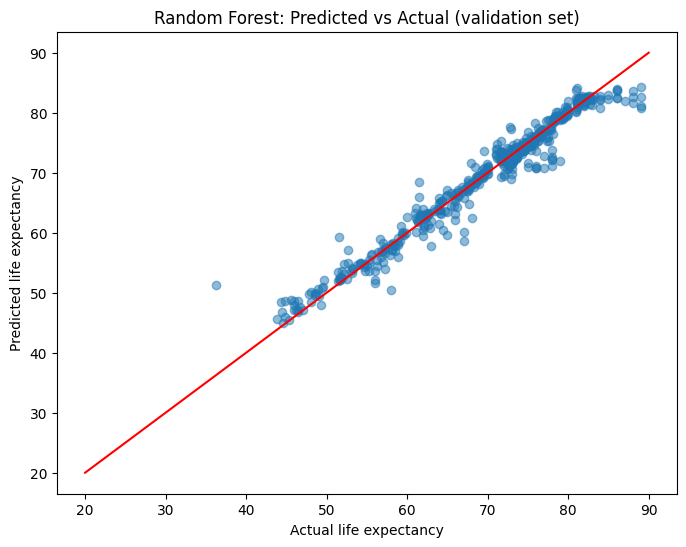

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_rf, alpha=0.5)
plt.plot([20, 90], [20, 90], 'r')
plt.title('Random Forest: Predicted vs Actual (validation set)')
plt.xlabel('Actual life expectancy')
plt.ylabel('Predicted life expectancy');

This gives a solid validation RMSE and the scatter plot stays close to the diagonal, so I moved on to trying a couple of other model families for comparison.

### 5.1 Sanity-checking against scikit-learn's RandomForestRegressor

Since I built the Random Forest from scratch, I wanted an independent check that the implementation itself is sound, separate from how well the *approach* works. I fit scikit-learn's `RandomForestRegressor` with the same tuned `n_estimators`, `max_depth`, and `max_samples` (scikit-learn's bootstrap-sample-size parameter) and compared validation RMSE against my own implementation.

In [20]:
sklearn_rf_model = RandomForestRegressor(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    max_samples=best_params_rf['max_samples'],
    random_state=RANDOM_STATE,
)
sklearn_rf_model.fit(X_train, y_train)

y_val_pred_sklearn_rf = sklearn_rf_model.predict(X_val)
rmse_val_sklearn_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_sklearn_rf))

print(f'Validation RMSE (my CustomRandomForest): {rmse_val_rf:.4f}')
print(f'Validation RMSE (sklearn RandomForestRegressor): {rmse_val_sklearn_rf:.4f}')

Validation RMSE (my CustomRandomForest): 1.9802
Validation RMSE (sklearn RandomForestRegressor): 1.9955


The validation RMSE came out at 1.9802 for my implementation versus 1.9955 for scikit-learn's - under 1% apart, and mine is marginally lower. That's a good indication the core bagging logic is implemented correctly.

### 5.2 Feature importance

`CustomRandomForest` doesn't expose an aggregated `feature_importances_` the way scikit-learn's does, but every underlying `DecisionTreeRegressor` already computes its own variance-reduction-based importances after fitting. Averaging those across all trees in the ensemble gives an aggregate ranking for the forest as a whole - this is what actually answers "which indicators carried the most predictive weight" from my CV summary, rather than just inferring it from the earlier correlation check (which, as noted above, isn't a reliable signal for `Country` specifically, and is only a linear signal for everything else).

In [21]:
tree_importances = np.array([tree.feature_importances_ for tree in best_rf_model.models])
feature_importance = pd.Series(tree_importances.mean(axis=0), index=X_train.columns).sort_values(ascending=False)
feature_importance

HIV/AIDS                           0.608390
Adult Mortality                    0.153335
Income composition of resources    0.089945
under-five deaths                  0.029652
Status                             0.020433
Schooling                          0.015865
BMI                                0.010703
infant deaths                      0.009526
thinness 5-9 years                 0.009220
Year                               0.007968
Alcohol                            0.007922
Total expenditure                  0.006949
Country                            0.004906
GDP                                0.004894
Polio                              0.004426
thinness 10-19 years               0.003898
Diphtheria                         0.003438
Measles                            0.003217
Hepatitis B                        0.002746
percentage expenditure             0.002566
dtype: float64

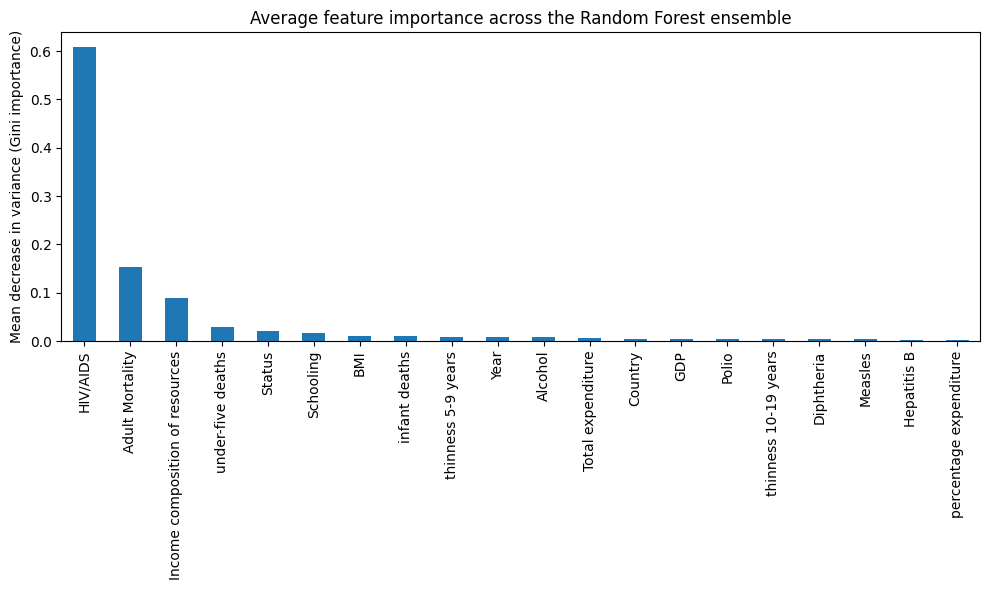

In [22]:
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Average feature importance across the Random Forest ensemble')
plt.ylabel('Mean decrease in variance (Gini importance)')
plt.tight_layout();

`HIV/AIDS` dominates the ranking at about 0.61 - far ahead of `Adult Mortality` (0.15) and `Income composition of resources` (~0.09). Together these three account for the large majority of the ensemble's splits, while immunization-coverage features (`Polio`, `Diphtheria`, `Hepatitis B`) and `percentage expenditure` barely register (each under 0.005). This is consistent with the training-set correlations from section 4.1, where `HIV/AIDS` and `Adult Mortality` were also among the strongest linear signals - so the two views agree here, which adds some confidence that this isn't just a quirk of how the trees happened to split.

Practically, this says the dataset's life-expectancy gap is dominated by mortality-related indicators (HIV/AIDS and adult mortality specifically) rather than by access-to-care indicators like immunization rates - plausible given how unevenly HIV/AIDS mortality is distributed across the countries in this dataset, but also a sign that `Adult Mortality` and `Income composition of resources` would likely take on more of the importance if `HIV/AIDS` weren't available, since they're probably correlated with it.

## 6. Ridge Regression

Ridge is a good fit here because L2 regularization handles correlated predictors well, and several of the health/immunization features in this dataset are correlated with each other. I tuned `alpha` (plus `max_iter` and `tol`) with grid search.

Best hyperparameters (Ridge): {'alpha': 1, 'max_iter': 100, 'tol': 0.0001}
Validation RMSE (Ridge): 4.1366


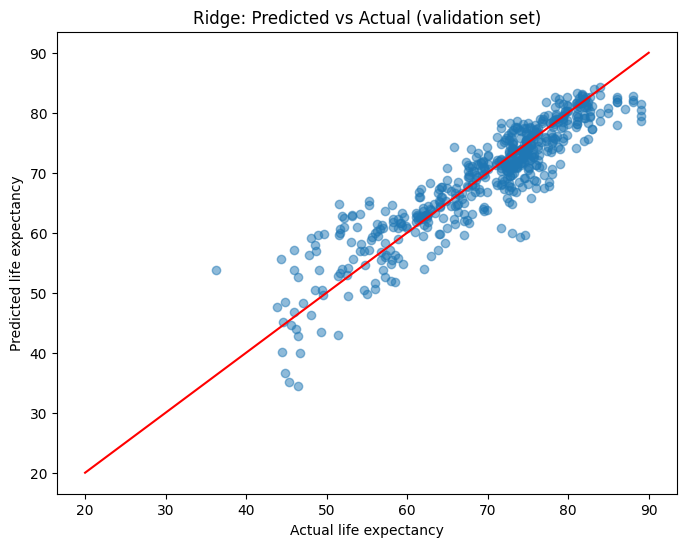

In [23]:
param_grid_ridge = {
    'alpha': [0.01, 0.1, 0.5, 1, 2],
    'max_iter': [100, 500, 1000],
    'tol': [1e-4, 1e-3, 1e-2],
}

grid_search_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
grid_search_ridge.fit(X_train, y_train)

best_params_ridge = grid_search_ridge.best_params_
print(f'Best hyperparameters (Ridge): {best_params_ridge}')

best_ridge_model = Ridge(**best_params_ridge)
best_ridge_model.fit(X_train, y_train)

y_val_pred_ridge = best_ridge_model.predict(X_val)
rmse_val_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
print(f'Validation RMSE (Ridge): {rmse_val_ridge:.4f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_ridge, alpha=0.5)
plt.plot([20, 90], [20, 90], 'r')
plt.title('Ridge: Predicted vs Actual (validation set)')
plt.xlabel('Actual life expectancy')
plt.ylabel('Predicted life expectancy');

Ridge is sensitive to feature scale, so I also tried it with standardized features to see whether that would close the gap with the Random Forest.

In [24]:
scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_val_sc = scaler.transform(X_val)

grid_search_ridge_sc = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
grid_search_ridge_sc.fit(X_train_sc, y_train)
best_ridge_sc_model = Ridge(**grid_search_ridge_sc.best_params_).fit(X_train_sc, y_train)

rmse_val_ridge_sc = np.sqrt(mean_squared_error(y_val, best_ridge_sc_model.predict(X_val_sc)))
print(f'Validation RMSE (Ridge, standardized features): {rmse_val_ridge_sc:.4f}')

Validation RMSE (Ridge, standardized features): 4.1379


Standardization didn't meaningfully change the result, Ridge still trails the Random Forest, so scaling wasn't the bottleneck here.

## 7. AdaBoost

As a third option I tried AdaBoost, tuning `n_estimators`, `learning_rate`, and `loss`.

Best hyperparameters (AdaBoost): {'learning_rate': 3, 'loss': 'linear', 'n_estimators': 200}
Validation RMSE (AdaBoost): 3.0777


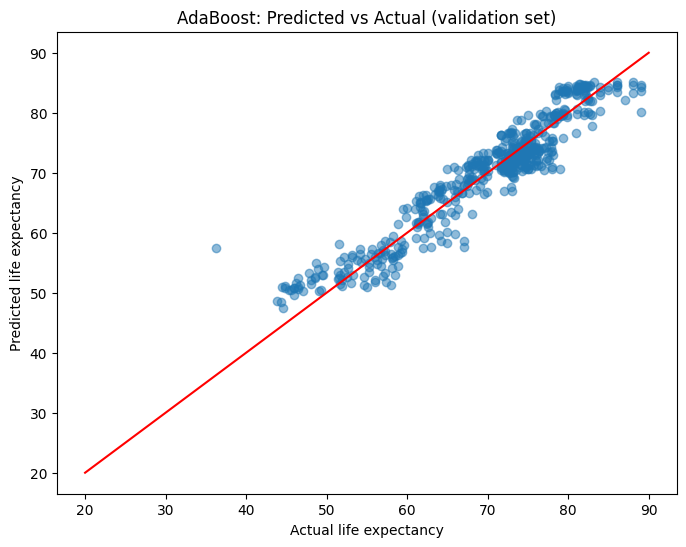

In [25]:
param_grid_ada = {
    'n_estimators': [5, 30, 60, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 0.6, 0.7, 1, 2, 3],
    'loss': ['linear', 'square', 'exponential'],
}

grid_search_ada = GridSearchCV(AdaBoostRegressor(random_state=RANDOM_STATE), param_grid_ada, cv=5, scoring='neg_mean_squared_error')
grid_search_ada.fit(X_train, y_train)

best_params_ada = grid_search_ada.best_params_
print(f'Best hyperparameters (AdaBoost): {best_params_ada}')

best_ada_model = AdaBoostRegressor(**best_params_ada, random_state=RANDOM_STATE)
best_ada_model.fit(X_train, y_train)

y_val_pred_ada = best_ada_model.predict(X_val)
rmse_val_ada = np.sqrt(mean_squared_error(y_val, y_val_pred_ada))
print(f'Validation RMSE (AdaBoost): {rmse_val_ada:.4f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_pred_ada, alpha=0.5)
plt.plot([20, 90], [20, 90], 'r')
plt.title('AdaBoost: Predicted vs Actual (validation set)')
plt.xlabel('Actual life expectancy')
plt.ylabel('Predicted life expectancy');

AdaBoost lands between Ridge and the Random Forest - better than plain regression, but still not as strong as the ensemble of trees.

## 8. Final model selection

The custom Random Forest has the lowest validation RMSE of the three, so I selected it as the final model. I refit it on the training data and report both RMSE and MAE on the untouched test set for an unbiased estimate of generalization error.

In [26]:
y_test_pred_rf = best_rf_model.predict(X_test)

rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f'Test RMSE (Random Forest): {rmse_test_rf:.4f}')
print(f'Test MAE (Random Forest): {mae_test_rf:.4f}')

Test RMSE (Random Forest): 1.8833
Test MAE (Random Forest): 1.1263


Test performance is close to validation performance, which suggests the model isn't overfitting to the validation set.

### 8.1 Residual analysis

RMSE and MAE compress the test-set errors into single numbers, which can hide whether the error is spread out evenly or concentrated in particular cases. I plotted the residuals against the predicted values, and their overall distribution, to check for patterns the two summary metrics alone wouldn't show - for example, whether the model is systematically less accurate at the low or high end of the life-expectancy range.

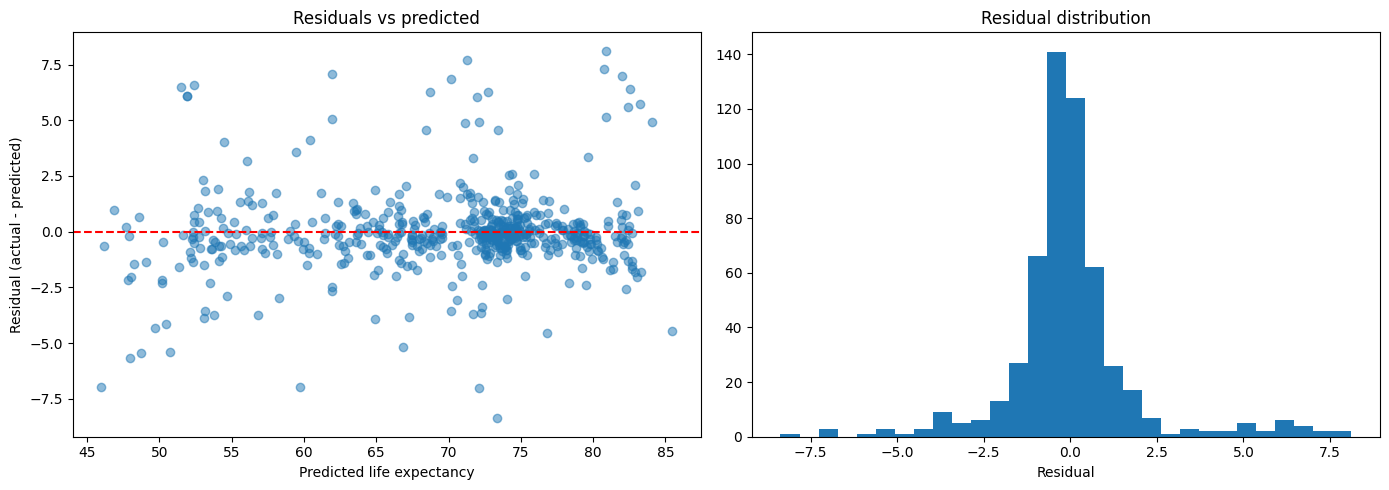

In [27]:
residuals = y_test - y_test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_pred_rf, residuals, alpha=0.5)
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted life expectancy')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs predicted')

axes[1].hist(residuals, bins=30)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual distribution')

plt.tight_layout();

In practice, the residuals are tightly clustered around zero with no visible funnel shape - the spread doesn't widen at higher or lower predicted values, so the model's error is fairly consistent across the range rather than degrading at the extremes. There's a small number of outliers reaching about ±8 years, scattered across the predicted range rather than concentrated at one end. The histogram is roughly bell-shaped and centered near zero, mostly within about ±2.5 years, with a slight tail toward positive residuals - a handful of cases where the true life expectancy came in higher than predicted, more often than the reverse. Nothing here points to a systematic weak spot the aggregate RMSE/MAE would be hiding.

## 9. Predicting on the evaluation set

Finally, I apply the exact same preprocessing pipeline to the held-out evaluation set: the same `Status` correction rule, the same fixed `Country`/`Status` code mapping from section 2.2 (not a freshly re-derived one - that was the bug in an earlier version of this notebook, where re-encoding the evaluation set on its own could silently assign a `Country` code to the wrong country), dropping `Population`, the renamed thinness column, and the per-country/global median imputation fit on the training set in section 4.2.

In [28]:
evaluation = pd.read_csv('evaluation.csv')

In [29]:
evaluation.head()

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Azerbaijan,2015,Developing,118.0,5,NaN,0.000000,96.0,0,52.5,...,98.0,NaN,96.0,0.1,55.313820,9649341.0,2.8,2.9,0.758,12.7
1,Azerbaijan,2014,Developing,119.0,5,0.01,306.182431,94.0,0,51.5,...,97.0,6.40,94.0,0.1,7891.299776,953579.0,2.8,2.9,0.752,12.2
2,Azerbaijan,2013,Developing,121.0,5,2.14,275.651493,93.0,164,5.6,...,96.0,5.54,93.0,0.1,7875.756953,941681.0,2.8,2.8,0.745,11.9
3,Azerbaijan,2012,Developing,123.0,5,0.01,285.610391,88.0,0,49.7,...,92.0,5.37,89.0,0.1,7496.335728,9295784.0,2.8,2.8,0.742,11.8
4,Azerbaijan,2011,Developing,125.0,5,1.98,263.142699,84.0,0,48.8,...,91.0,5.10,87.0,0.1,7189.691229,917382.0,2.8,2.9,0.741,11.7


In [30]:
evaluation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          210 non-null    object 
 1   Year                             210 non-null    int64  
 2   Status                           210 non-null    object 
 3   Adult Mortality                  210 non-null    float64
 4   infant deaths                    210 non-null    int64  
 5   Alcohol                          171 non-null    float64
 6   percentage expenditure           210 non-null    float64
 7   Hepatitis B                      187 non-null    float64
 8   Measles                          210 non-null    int64  
 9   BMI                              204 non-null    float64
 10  under-five deaths                210 non-null    int64  
 11  Polio                            209 non-null    float64
 12  Total expenditure     

In [31]:
developed_countries_eval = ['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Canada', 'Croatia',
    'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France',
    'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel',
    'Italy', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
    'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal',
    'Republic of Korea', 'Romania', 'Singapore', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden', 'Switzerland',
    'United Kingdom of Great Britain and Northern Ireland',
    'United States of America']
evaluation.loc[evaluation['Country'].isin(developed_countries_eval), 'Status'] = 'Developed'

I set `Country` and `Year` aside first, since the categorical encoding below would otherwise make them hard to recover for the final results table.

In [32]:
country_year_info = evaluation[['Country', 'Year']].copy()

evaluation['Country'] = pd.Categorical(evaluation['Country'], categories=country_categories).codes
evaluation['Status'] = pd.Categorical(evaluation['Status'], categories=status_categories).codes

evaluation = evaluation.drop(columns=['Population'])
evaluation = evaluation.rename(columns={'thinness  1-19 years': 'thinness 10-19 years'})
evaluation = impute_with_country_median(evaluation, country_medians, global_medians)

evaluation.head()

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 10-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,9,2015,1,118.0,5,0.62,0.000000,96.0,0,52.5,6,98.0,5.10,96.0,0.1,55.313820,2.8,2.9,0.758,12.7
1,9,2014,1,119.0,5,0.01,306.182431,94.0,0,51.5,6,97.0,6.40,94.0,0.1,7891.299776,2.8,2.9,0.752,12.2
2,9,2013,1,121.0,5,2.14,275.651493,93.0,164,5.6,6,96.0,5.54,93.0,0.1,7875.756953,2.8,2.8,0.745,11.9
3,9,2012,1,123.0,5,0.01,285.610391,88.0,0,49.7,6,92.0,5.37,89.0,0.1,7496.335728,2.8,2.8,0.742,11.8
4,9,2011,1,125.0,5,1.98,263.142699,84.0,0,48.8,6,91.0,5.10,87.0,0.1,7189.691229,2.8,2.9,0.741,11.7


A country in the evaluation set that never appeared in the training data at all would get `Country` code `-1` from `pd.Categorical` (rather than colliding with a real training country's code), and would fall back to the global training median for every feature via `impute_with_country_median` - the model would still produce a prediction for it, just a less country-specific one. I didn't hit this case with the current evaluation set, but it's worth knowing the pipeline degrades gracefully rather than silently mis-assigning the row to some other country.

In [33]:
predictions = best_rf_model.predict(evaluation).round(1)

results = country_year_info.copy()
results['Life expectancy'] = predictions
results.to_csv('results.csv', index=False)

results.head()

,Country,Year,Life expectancy
0,Azerbaijan,2015,74.6
1,Azerbaijan,2014,74.6
2,Azerbaijan,2013,74.6
3,Azerbaijan,2012,74.4
4,Azerbaijan,2011,74.3


The predictions look plausible on a sanity check: countries like Japan and Norway come out above 80 years, while countries like the Democratic Republic of the Congo and Malawi come out under 60, which matches real-world expectations.

## 10. Conclusion

The custom Random Forest was the strongest of the three models by a clear margin - validation RMSE of 1.98 years versus 3.08 for AdaBoost and 4.14 for Ridge (standardizing features didn't change Ridge's result, so the gap isn't about feature scale). On the untouched test set it reached an RMSE of 1.88 years and an MAE of 1.13 years, close to (in fact slightly better than) its validation score, which is a reasonable indication it isn't overfitting to the validation split. Sanity-checking it against scikit-learn's own `RandomForestRegressor` under the same hyperparameters produced a near-identical RMSE (1.98 vs 2.00), which gives some confidence the from-scratch bagging implementation itself is sound rather than just fortunate.

The feature-importance analysis and the residual plots both point in a consistent direction: `HIV/AIDS` and `Adult Mortality` carry most of the model's predictive power, the errors don't grow or shrink systematically across the predicted range, and the largest mistakes (up to about ±8 years) are scattered rather than concentrated in one part of the data - so the reported RMSE/MAE aren't hiding an obvious blind spot.

**Main limitations:**

* `Country` is still an arbitrarily-coded categorical ID rather than a true numeric or one-hot feature, a tree-based model can still exploit it through repeated splits, but it isn't the most principled encoding, and its low importance (~0.005) here could partly reflect that.
* Rows are treated as independent, even though the dataset has a real time dimension (`Year`, 2000-2015 per country), a country's values in one year are correlated with its values in the next, which a random train/val/test split ignores. A split by year (train on earlier years, test on later ones) would be a more realistic test of the model's ability to generalize forward in time.
* Per-country median imputation is an improvement over a single global median, but it still assumes a country's missing values look like its *other* years - for countries with very few training rows, or fast-changing indicators, that assumption is weaker.
* The heavy reliance on `HIV/AIDS` and `Adult Mortality` means the model may generalize less well to countries or periods where those indicators behave differently than they did in this dataset.